In [75]:
## import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df=pd.read_csv('train.csv')

In [77]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [78]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: xlabel='Age', ylabel='Count'>

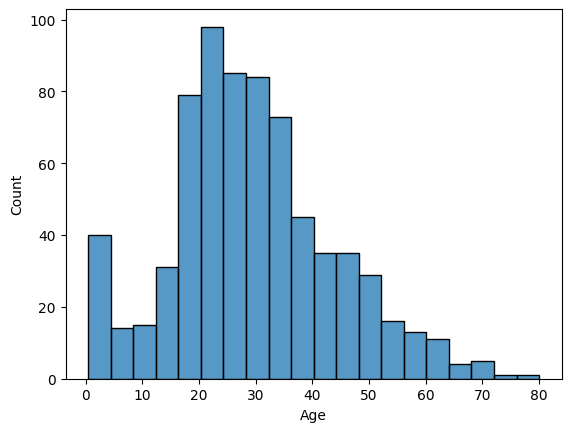

In [80]:
sns.histplot(df['Age'])## finding outliers

<Axes: ylabel='Fare'>

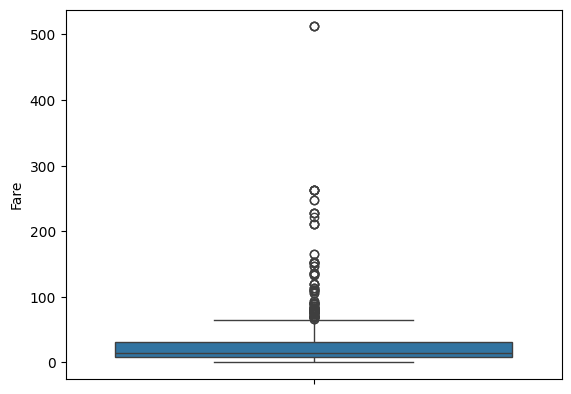

In [81]:
sns.boxplot(df['Fare'])

<Axes: ylabel='Age'>

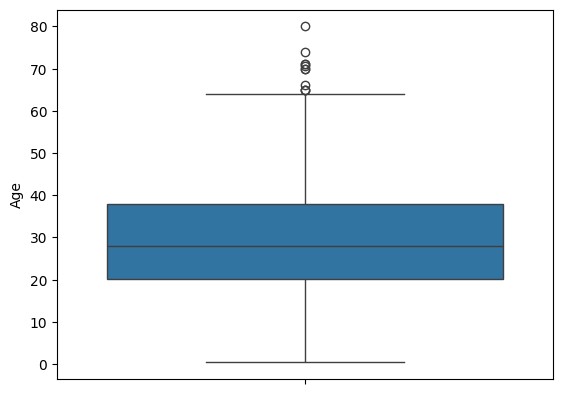

In [82]:
sns.boxplot(df['Age'])

In [83]:
df['Age']=df['Age'].replace(np.nan,0)

In [84]:
Num_key=['Age','Fare']

Q1={}
for i  in Num_key:
    Q1[i]=np.percentile(df[i],25).round(2)

Q1

{'Age': np.float64(6.0), 'Fare': np.float64(7.91)}

In [85]:
Q3={}
for i  in Num_key:
    Q3[i]=np.percentile(df[i],75).round(2)

Q3

{'Age': np.float64(35.0), 'Fare': np.float64(31.0)}

In [86]:
IQR={}
for i  in Num_key:
    IQR[i]=int(Q3[i])-int(Q1[i])

IQR

{'Age': 29, 'Fare': 24}

In [87]:
UF={}
LF={}
for i  in Num_key:
    UF[i]=(int(Q3[i])+(1.5*int(IQR[i])))
UF

{'Age': 78.5, 'Fare': 67.0}

In [88]:
for i in Num_key:
    LF[i]=(int(Q1[i])-(1.5*int(IQR[i])))

LF

{'Age': -37.5, 'Fare': -29.0}

In [89]:
Col_key=['Age','Fare']
for i in Col_key:
    df=df[(df[i]<=UF[i]) & (df[i]>=0)]
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,776.000000,776.000000,776.000000,776.00000,776.000000,776.000000,776.000000
mean,445.048969,0.338918,2.478093,22.82893,0.439433,0.340206,17.932114
std,260.105765,0.473647,0.735836,17.24523,0.899572,0.785502,13.786338
min,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000
25%,212.750000,0.000000,2.000000,4.00000,0.000000,0.000000,7.895800
50%,448.500000,0.000000,3.000000,24.00000,0.000000,0.000000,13.000000
75%,670.250000,1.000000,3.000000,34.00000,1.000000,0.000000,26.000000
max,891.000000,1.000000,3.000000,74.00000,5.000000,6.000000,66.600000


In [90]:
df['Age']=df['Age'].replace(0,df['Age'].mean())

In [91]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,22.82893,0,0,330877,8.4583,NaN,Q


In [92]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000,776.000000
mean,445.048969,0.338918,2.478093,27.594764,0.439433,0.340206,17.932114
std,260.105765,0.473647,0.735836,12.873081,0.899572,0.785502,13.786338
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,212.750000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,448.500000,0.000000,3.000000,24.000000,0.000000,0.000000,13.000000
75%,670.250000,1.000000,3.000000,34.000000,1.000000,0.000000,26.000000
max,891.000000,1.000000,3.000000,74.000000,5.000000,6.000000,66.600000


In [93]:
df['Survived'].value_counts()

Survived
0    513
1    263
Name: count, dtype: int64

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 776 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  776 non-null    int64  
 1   Survived     776 non-null    int64  
 2   Pclass       776 non-null    int64  
 3   Name         776 non-null    object 
 4   Sex          776 non-null    object 
 5   Age          776 non-null    float64
 6   SibSp        776 non-null    int64  
 7   Parch        776 non-null    int64  
 8   Ticket       776 non-null    object 
 9   Fare         776 non-null    float64
 10  Cabin        115 non-null    object 
 11  Embarked     776 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 78.8+ KB


In [95]:
df['Pclass'].value_counts()

Pclass
3    484
2    179
1    113
Name: count, dtype: int64

In [96]:
df['Sex'].value_counts()

Sex
male      531
female    245
Name: count, dtype: int64

In [97]:
df['SibSp'].value_counts()

SibSp
0    556
1    163
2     21
4     18
3     13
5      5
Name: count, dtype: int64

In [98]:
df['Parch'].value_counts()

Parch
0    610
1     98
2     54
5      5
3      5
4      3
6      1
Name: count, dtype: int64

In [99]:
df=df.drop('Ticket',axis=1)

In [100]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,22.82893,0,0,8.4583,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00000,0,0,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00000,0,0,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.82893,1,2,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00000,0,0,30.0000,C148,C


In [101]:
df['Cabin'].value_counts()

Cabin
G6             4
E101           3
F33            3
F2             3
D              3
              ..
E17            1
A24            1
B51 B53 B55    1
B42            1
C148           1
Name: count, Length: 87, dtype: int64

In [102]:
df['Cabin']=df['Cabin'].replace(np.nan,0)

In [103]:
df['Has_Cabin']=df['Cabin']

In [104]:
df=df.drop('Cabin',axis=1)

In [105]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,7.2500,S,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,53.1000,S,C123
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,8.0500,S,0
5,6,0,3,"Moran, Mr. James",male,22.82893,0,0,8.4583,Q,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00000,0,0,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00000,0,0,30.0000,S,B42
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.82893,1,2,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00000,0,0,30.0000,C,C148


In [106]:
df['Has_Cabin']=np.where(df['Has_Cabin']!=0,1,0)

In [107]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,7.2500,S,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,8.0500,S,0
5,6,0,3,"Moran, Mr. James",male,22.82893,0,0,8.4583,Q,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00000,0,0,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00000,0,0,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.82893,1,2,23.4500,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00000,0,0,30.0000,C,1


In [108]:
df['Embarked'].value_counts()

Embarked
S    585
C    116
Q     75
Name: count, dtype: int64

In [109]:
df['Embarked']=df['Embarked'].replace(1,'S')

In [110]:
df['Embarked'].value_counts()

Embarked
S    585
C    116
Q     75
Name: count, dtype: int64

In [111]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,7.2500,S,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,8.0500,S,0
5,6,0,3,"Moran, Mr. James",male,22.82893,0,0,8.4583,Q,0


In [112]:
df=pd.get_dummies(df,columns=['Pclass','Embarked'])
df=pd.get_dummies(df,columns=['Sex'],drop_first=True)

In [113]:
df

,PassengerId,Survived,Name,Age,SibSp,Parch,Fare,Has_Cabin,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,1,0,"Braund, Mr. Owen Harris",22.00000,1,0,7.2500,0,False,False,True,False,False,True,True
2,3,1,"Heikkinen, Miss. Laina",26.00000,0,0,7.9250,0,False,False,True,False,False,True,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00000,1,0,53.1000,1,True,False,False,False,False,True,False
4,5,0,"Allen, Mr. William Henry",35.00000,0,0,8.0500,0,False,False,True,False,False,True,True
5,6,0,"Moran, Mr. James",22.82893,0,0,8.4583,0,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.00000,0,0,13.0000,0,False,True,False,False,False,True,True
887,888,1,"Graham, Miss. Margaret Edith",19.00000,0,0,30.0000,1,True,False,False,False,False,True,False
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",22.82893,1,2,23.4500,0,False,False,True,False,False,True,False
889,890,1,"Behr, Mr. Karl Howell",26.00000,0,0,30.0000,1,True,False,False,True,False,False,True


In [114]:
df[['Pclass_2','Pclass_3','Embarked_C','Pclass_1','Embarked_S','Embarked_Q']]=df[['Pclass_2','Pclass_3','Embarked_C','Pclass_1','Embarked_S','Embarked_Q']].astype(int)

In [115]:
df

,PassengerId,Survived,Name,Age,SibSp,Parch,Fare,Has_Cabin,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,1,0,"Braund, Mr. Owen Harris",22.00000,1,0,7.2500,0,0,0,1,0,0,1,True
2,3,1,"Heikkinen, Miss. Laina",26.00000,0,0,7.9250,0,0,0,1,0,0,1,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00000,1,0,53.1000,1,1,0,0,0,0,1,False
4,5,0,"Allen, Mr. William Henry",35.00000,0,0,8.0500,0,0,0,1,0,0,1,True
5,6,0,"Moran, Mr. James",22.82893,0,0,8.4583,0,0,0,1,0,1,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.00000,0,0,13.0000,0,0,1,0,0,0,1,True
887,888,1,"Graham, Miss. Margaret Edith",19.00000,0,0,30.0000,1,1,0,0,0,0,1,False
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",22.82893,1,2,23.4500,0,0,0,1,0,0,1,False
889,890,1,"Behr, Mr. Karl Howell",26.00000,0,0,30.0000,1,1,0,0,1,0,0,True


In [116]:
from sklearn.preprocessing import StandardScaler
Col=['Age','Fare','Parch','SibSp']
scaler=StandardScaler()
df[Col]=scaler.fit_transform(df[Col])

In [117]:
df

,PassengerId,Survived,Name,Age,SibSp,Parch,Fare,Has_Cabin,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,1,0,"Braund, Mr. Owen Harris",-0.434890,0.623550,-0.433386,-0.775333,0,0,0,1,0,0,1,True
2,3,1,"Heikkinen, Miss. Laina",-0.123964,-0.488806,-0.433386,-0.726340,0,0,0,1,0,0,1,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.575621,0.623550,-0.433386,2.552568,1,1,0,0,0,0,1,False
4,5,0,"Allen, Mr. William Henry",0.575621,-0.488806,-0.433386,-0.717267,0,0,0,1,0,0,1,True
5,6,0,"Moran, Mr. James",-0.370456,-0.488806,-0.433386,-0.687632,0,0,0,1,0,1,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",-0.046232,-0.488806,-0.433386,-0.357984,0,0,1,0,0,0,1,True
887,888,1,"Graham, Miss. Margaret Edith",-0.668085,-0.488806,-0.433386,0.875916,1,1,0,0,0,0,1,False
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",-0.370456,0.623550,2.114398,0.400501,0,0,0,1,0,0,1,False
889,890,1,"Behr, Mr. Karl Howell",-0.123964,-0.488806,-0.433386,0.875916,1,1,0,0,1,0,0,True


In [118]:
df.to_csv('train_cleaned.csv')

In [119]:
## Parameter Tuning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score,recall_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [120]:
models={
    'LogisticRegression':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'SVM':SVC(),
    'DT':DecisionTreeClassifier()
}

In [121]:
x=df.drop(columns=['Survived','Name'],axis=1)
y=df['Survived']

In [122]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [123]:
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({
        'model':name,
        'Accuracy':round(acc,4),
        'Recall':round(recall,4),
        'F1':round(f1,4)
    })


In [124]:
results

[{'model': 'LogisticRegression',
  'Accuracy': 0.7692,
  'Recall': 0.5965,
  'F1': 0.6538},
 {'model': 'KNN', 'Accuracy': 0.5513, 'Recall': 0.1754, 'F1': 0.2222},
 {'model': 'SVM', 'Accuracy': 0.6346, 'Recall': 0.0, 'F1': 0.0},
 {'model': 'DT', 'Accuracy': 0.7821, 'Recall': 0.7018, 'F1': 0.7018}]

In [125]:
##Checking the best hyperparameters for KNN
knn_model=KNeighborsClassifier()
knn_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [126]:
classifier_knn=GridSearchCV(knn_model,{
    'weights':['uniform','distance'],
    'n_neighbors':[3,5,7,9],
    'algorithm':['auto','ball_tree','kd_tree','brute'],
    'leaf_size':[30,40,50,60]
 },cv=5,return_train_score=False)

In [127]:
classifier_knn.fit(x,y)

,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'leaf_size': [30, 40, ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [128]:
classifier_knn.cv_results_

{'mean_fit_time': array([0.01036997, 0.00832257, 0.00289383, 0.00356135, 0.00602832,
        0.00224328, 0.00570378, 0.00369062, 0.00331006, 0.0048892 ,
        0.00278158, 0.00508432, 0.00106587, 0.00316629, 0.00084586,
        0.00783453, 0.0022089 , 0.00328417, 0.00161757, 0.00543642,
        0.00674925, 0.02217464, 0.01006398, 0.00166674, 0.00642114,
        0.00111818, 0.00411215, 0.00211978, 0.00149364, 0.00226688,
        0.00342474, 0.00120425, 0.00365858, 0.00472736, 0.0020287 ,
        0.00740595, 0.        , 0.00143957, 0.00186992, 0.00679474,
        0.00462632, 0.00337296, 0.00635529, 0.00562625, 0.00531812,
        0.00441914, 0.        , 0.00080333, 0.00316072, 0.00679998,
        0.0065496 , 0.00225778, 0.00080323, 0.00586562, 0.00705132,
        0.00663958, 0.00282335, 0.00407143, 0.00220881, 0.00565295,
        0.00252662, 0.00200868, 0.00229535, 0.00355659, 0.00220985,
        0.0064363 , 0.00190969, 0.00293326, 0.00660052, 0.0046011 ,
        0.00196157, 0.00530257,

In [129]:
pd.DataFrame(classifier_knn.cv_results_).sort_values('mean_test_score',ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.010370,0.007604,0.011988,0.002379,auto,30,3,uniform,"{'algorithm': 'auto', 'leaf_size': 30, 'n_neig...",0.660256,0.535484,0.438710,0.412903,0.658065,0.541084,0.104717,1
1,0.008323,0.003250,0.005096,0.004112,auto,30,3,distance,"{'algorithm': 'auto', 'leaf_size': 30, 'n_neig...",0.660256,0.535484,0.438710,0.412903,0.658065,0.541084,0.104717,1
9,0.004889,0.001668,0.003485,0.001543,auto,40,3,distance,"{'algorithm': 'auto', 'leaf_size': 40, 'n_neig...",0.660256,0.535484,0.438710,0.412903,0.658065,0.541084,0.104717,1
8,0.003310,0.002044,0.003231,0.003007,auto,40,3,uniform,"{'algorithm': 'auto', 'leaf_size': 40, 'n_neig...",0.660256,0.535484,0.438710,0.412903,0.658065,0.541084,0.104717,1
24,0.006421,0.006594,0.002724,0.003364,auto,60,3,uniform,"{'algorithm': 'auto', 'leaf_size': 60, 'n_neig...",0.660256,0.535484,0.438710,0.412903,0.658065,0.541084,0.104717,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,0.003792,0.005069,0.004835,0.004867,kd_tree,40,9,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 40, 'n_n...",0.660256,0.516129,0.419355,0.400000,0.658065,0.530761,0.111981,113
110,0.002210,0.003502,0.008805,0.002887,brute,40,9,uniform,"{'algorithm': 'brute', 'leaf_size': 40, 'n_nei...",0.660256,0.516129,0.419355,0.400000,0.658065,0.530761,0.111981,113
102,0.005353,0.003870,0.005778,0.003239,brute,30,9,uniform,"{'algorithm': 'brute', 'leaf_size': 30, 'n_nei...",0.660256,0.516129,0.419355,0.400000,0.658065,0.530761,0.111981,113
118,0.003623,0.003761,0.005547,0.003158,brute,50,9,uniform,"{'algorithm': 'brute', 'leaf_size': 50, 'n_nei...",0.660256,0.516129,0.419355,0.400000,0.658065,0.530761,0.111981,113


In [130]:
model_log=LogisticRegression()
model_log.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [131]:
classifier_log=GridSearchCV(model_log,{
    'C':[0.01,0.1,1],
    'penalty':['l1','l2'],
    'l1_ratio':[0.1,0.5,0.7,0.9]
},cv=5,return_train_score=False)

In [132]:
classifier_log.fit(x,y)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'l1_ratio': [0.1, 0.5, ...], 'penalty': ['l1', 'l2']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [133]:
pd.DataFrame(classifier_log.cv_results_).sort_values('mean_test_score',ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,param_penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
17,0.027113,0.006540,0.001708,0.001542,1.00,0.1,l2,"{'C': 1, 'l1_ratio': 0.1, 'penalty': 'l2'}",0.775641,0.767742,0.806452,0.774194,0.819355,0.788677,0.020372,1
19,0.023981,0.004193,0.003172,0.002510,1.00,0.5,l2,"{'C': 1, 'l1_ratio': 0.5, 'penalty': 'l2'}",0.775641,0.767742,0.806452,0.774194,0.819355,0.788677,0.020372,1
21,0.022506,0.005968,0.005139,0.006152,1.00,0.7,l2,"{'C': 1, 'l1_ratio': 0.7, 'penalty': 'l2'}",0.775641,0.767742,0.806452,0.774194,0.819355,0.788677,0.020372,1
23,0.024995,0.003040,0.002749,0.003818,1.00,0.9,l2,"{'C': 1, 'l1_ratio': 0.9, 'penalty': 'l2'}",0.775641,0.767742,0.806452,0.774194,0.819355,0.788677,0.020372,1
15,0.023253,0.007398,0.006748,0.005583,0.10,0.9,l2,"{'C': 0.1, 'l1_ratio': 0.9, 'penalty': 'l2'}",0.775641,0.774194,0.793548,0.774194,0.806452,0.784806,0.013071,5
13,0.029988,0.008377,0.003298,0.002890,0.10,0.7,l2,"{'C': 0.1, 'l1_ratio': 0.7, 'penalty': 'l2'}",0.775641,0.774194,0.793548,0.774194,0.806452,0.784806,0.013071,5
11,0.025264,0.007778,0.001418,0.001767,0.10,0.5,l2,"{'C': 0.1, 'l1_ratio': 0.5, 'penalty': 'l2'}",0.775641,0.774194,0.793548,0.774194,0.806452,0.784806,0.013071,5
9,0.023329,0.006178,0.003646,0.003741,0.10,0.1,l2,"{'C': 0.1, 'l1_ratio': 0.1, 'penalty': 'l2'}",0.775641,0.774194,0.793548,0.774194,0.806452,0.784806,0.013071,5
7,0.024232,0.001701,0.002306,0.003033,0.01,0.9,l2,"{'C': 0.01, 'l1_ratio': 0.9, 'penalty': 'l2'}",0.698718,0.709677,0.722581,0.716129,0.716129,0.712647,0.008072,9
5,0.020156,0.003526,0.003060,0.003845,0.01,0.7,l2,"{'C': 0.01, 'l1_ratio': 0.7, 'penalty': 'l2'}",0.698718,0.709677,0.722581,0.716129,0.716129,0.712647,0.008072,9


In [134]:
model_svm=SVC()
model_svm.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [135]:
classifier_svm=GridSearchCV(model_svm,{
    'C':[0.01,0.1,1],
    'gamma':['scale','auto']
},cv=5,return_train_score=False)

In [136]:
classifier_svm.fit(x,y)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [137]:
pd.DataFrame(classifier_svm.cv_results_).sort_values('mean_test_score',ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.037829,0.013991,0.025029,0.021158,0.01,scale,"{'C': 0.01, 'gamma': 'scale'}",0.660256,0.664516,0.664516,0.658065,0.658065,0.661084,0.002915,1
1,0.032493,0.007423,0.013306,0.002750,0.01,auto,"{'C': 0.01, 'gamma': 'auto'}",0.660256,0.664516,0.664516,0.658065,0.658065,0.661084,0.002915,1
2,0.022102,0.006201,0.008762,0.003338,0.10,scale,"{'C': 0.1, 'gamma': 'scale'}",0.660256,0.664516,0.664516,0.658065,0.658065,0.661084,0.002915,1
3,0.032135,0.002732,0.016373,0.003707,0.10,auto,"{'C': 0.1, 'gamma': 'auto'}",0.660256,0.664516,0.664516,0.658065,0.658065,0.661084,0.002915,1
4,0.030612,0.013546,0.009307,0.005522,1.00,scale,"{'C': 1, 'gamma': 'scale'}",0.660256,0.664516,0.664516,0.658065,0.658065,0.661084,0.002915,1
5,0.030639,0.008675,0.017728,0.004831,1.00,auto,"{'C': 1, 'gamma': 'auto'}",0.660256,0.651613,0.600000,0.606452,0.658065,0.635277,0.026403,6


In [138]:
model_Dt=DecisionTreeClassifier()
model_Dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [139]:
classifier_Dt=GridSearchCV(model_Dt,{
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'min_samples_split':[2,4,6,8]
})

In [140]:
classifier_Dt.fit(x,y)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'min_samples_split': [2, 4, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [141]:
pd.DataFrame(classifier_Dt.cv_results_).sort_values('mean_test_score',ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.005944,0.002118,0.002160,0.001628,gini,6,random,"{'criterion': 'gini', 'min_samples_split': 6, ...",0.775641,0.729032,0.800000,0.819355,0.838710,0.792548,0.038014,1
19,0.008035,0.002336,0.004415,0.004068,log_loss,4,random,"{'criterion': 'log_loss', 'min_samples_split':...",0.769231,0.748387,0.780645,0.793548,0.864516,0.791266,0.039516,2
13,0.003645,0.004622,0.001641,0.001559,entropy,6,random,"{'criterion': 'entropy', 'min_samples_split': ...",0.782051,0.735484,0.832258,0.787097,0.800000,0.787378,0.031289,3
15,0.003965,0.002764,0.002228,0.002740,entropy,8,random,"{'criterion': 'entropy', 'min_samples_split': ...",0.782051,0.690323,0.780645,0.780645,0.845161,0.775765,0.049403,4
7,0.001834,0.003669,0.004666,0.006306,gini,8,random,"{'criterion': 'gini', 'min_samples_split': 8, ...",0.685897,0.735484,0.825806,0.793548,0.812903,0.770728,0.052481,5
16,0.007427,0.006315,0.001354,0.001185,log_loss,2,best,"{'criterion': 'log_loss', 'min_samples_split':...",0.705128,0.761290,0.767742,0.774194,0.832258,0.768122,0.040411,6
3,0.002502,0.003504,0.003661,0.003186,gini,4,random,"{'criterion': 'gini', 'min_samples_split': 4, ...",0.743590,0.722581,0.735484,0.780645,0.858065,0.768073,0.048964,7
21,0.023010,0.016683,0.010208,0.007173,log_loss,6,random,"{'criterion': 'log_loss', 'min_samples_split':...",0.743590,0.735484,0.716129,0.819355,0.819355,0.766782,0.043843,8
18,0.006869,0.003813,0.002727,0.002858,log_loss,4,best,"{'criterion': 'log_loss', 'min_samples_split':...",0.705128,0.761290,0.741935,0.767742,0.851613,0.765542,0.048246,9
10,0.006446,0.005475,0.003879,0.005222,entropy,4,best,"{'criterion': 'entropy', 'min_samples_split': ...",0.705128,0.761290,0.748387,0.767742,0.838710,0.764251,0.043156,10


In [142]:
## Stacking
from sklearn.ensemble import StackingClassifier
Learner=[
    ('svm',SVC(C=0.01,gamma='scale')),
    ('knn',KNeighborsClassifier(algorithm='auto',leaf_size=30,n_neighbors=3,weights='uniform')),
    ('log',LogisticRegression(C=1,penalty='l2',l1_ratio=0.1)),
]

In [143]:
Tester=DecisionTreeClassifier(criterion='log_loss',min_samples_split=8,splitter='random')

In [144]:
Classifier_stack=StackingClassifier(
    estimators=Learner,
    final_estimator=Tester,
    cv=5
)

In [145]:
Classifier_stack.fit(X_train,y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,final_estimator,DecisionTreeC...tter='random')
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,C,0.01
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [146]:
pred_stack=Classifier_stack.predict(X_test)

In [ ]:
accuracy_score(y_test,pred_stack)##accuracy of stacking

0.717948717948718

In [ ]:
recall_score(y_test,pred_stack)##recall of stacking

0.5087719298245614

In [150]:
## bagging
from sklearn.ensemble import RandomForestClassifier
random_classifier=RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [151]:
random_classifier.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [152]:
pred_random=random_classifier.predict(X_test)

In [ ]:
accuracy_score(y_test,pred_random)##accuracy of random forest

0.8269230769230769

In [155]:
recall_score(y_test,pred_random)##recall of random forest

0.6491228070175439

In [156]:
##Boosting
##Adabooster
from sklearn.ensemble import AdaBoostClassifier
ada_classifier=AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [157]:
ada_classifier.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [158]:
pred_ada=ada_classifier.predict(X_test)

In [159]:
accuracy_score(y_test,pred_ada)

0.8076923076923077

In [161]:
recall_score(y_test,pred_ada)

0.6666666666666666

In [162]:
##Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
Gradient_classifier=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42)

In [163]:
Gradient_classifier.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [164]:
pred_Grad=Gradient_classifier.predict(X_test)

In [165]:
accuracy_score(y_test,pred_Grad)

0.8461538461538461

In [166]:
recall_score(y_test,pred_Grad)

0.7368421052631579

In [167]:
from xgboost import XGBClassifier
xgb_classifier=XGBClassifier(n_estimators=100,learning_rate=0.1,random_state=42)

In [168]:
xgb_classifier.fit(X_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [169]:
pred_xgb=xgb_classifier.predict(X_test)

In [170]:
accuracy_score(y_test,pred_xgb)

0.8397435897435898

In [171]:
recall_score(y_test,pred_stack)

0.5087719298245614